In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Load Dataset from EIA

In [98]:
eia = pd.read_excel(
    "../data/raw/eia_sales_revenue.xlsx",
    header=[0, 1]
)

## Dataset Information - EIA

In [99]:
print("DataFrame shape:", eia.shape)
print(eia.describe())
print(eia.info())
print(eia.dtypes)
print(eia.columns)
eia.head(5)

DataFrame shape: (10100, 24)
       Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0  \
       Unnamed: 0_level_1 Unnamed: 1_level_1 Unnamed: 2_level_1   
count               10100              10099              10099   
unique                 19                 13                 52   
top                  2018                  6                 MS   
freq                  612                867                198   

       Unnamed: 3_level_0 RESIDENTIAL                             COMMERCIAL  \
       Unnamed: 3_level_1     Revenue    Sales Customers    Price    Revenue   
count               10099       10099    10099     10099  10099.0      10099   
unique                  3       10093    10097     10082   1965.0      10092   
top                 Final      274593  2232806    858643     11.6      36903   
freq                 9180           2        2         2     30.0          2   

                ... INDUSTRIAL           TRANSPORTATION                   \
         Sa

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
  Unnamed: 0_level_1 Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1   
0               Year              Month              State        Data Status   
1               2026                  6                 AK        Preliminary   
2               2026                  6                 AL        Preliminary   
3               2026                  6                 AR        Preliminary   
4               2026                  6                 AZ        Preliminary   

        RESIDENTIAL                                            COMMERCIAL  \
            Revenue          Sales Customers      Price           Revenue   
0  Thousand Dollars  Megawatthours     Count  Cents/kWh  Thousand Dollars   
1          39428.76      139789.34    305408      28.21          48089.48   
2         495417.89        3019973   2452755       16.4          307055.4   
3         231585.23      1639985.7   1508612      14.12          122669.2   
4         703261.47      4633130.1   3206137      15.18         496763.64   

                  ... INDUSTRIAL               TRANSPORTATION                 \
           Sales  ...  Customers      Price           Revenue          Sales   
0  Megawatthours  ...      Count  Cents/kWh  Thousand Dollars  Megawatthours   
1       205310.3  ...       1260      21.02                 0              0   
2      2092950.6  ...       7257       7.92                 0              0   
3      1063448.4  ...      38388       7.08              3.27          21.14   
4        3983125  ...       7130       7.73            114.67         965.55   

                                   TOTAL                                      
  Customers      Price           Revenue          Sales Customers      Price  
0     Count  Cents/kWh  Thousand Dollars  Megawatthours     Count  Cents/kWh  
1         0          0         111858.49      460878.92    364671      24.27  
2         0          0           1032506      8018606.6   2859151      12.88  
3         2      15.47         493877.47      4675265.8   1758238      10.56  
4         2      11.88         1304256.7        9964694   3567087      13.09  

[5 rows x 24 columns]

## Load Data from ATB

In [100]:
atb = pd.read_csv("../data/raw/atb_cost_data.csv")

/var/folders/dl/hxn409y91c15r_zkyvv6vpb80000gn/T/ipykernel_42640/2922840512.py:1: DtypeWarning: Columns (9,10,13,14,17,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  atb = pd.read_csv("../data/raw/atb_cost_data.csv")


## Dataset Information - ATB

In [101]:
print("DataFrame shape:", atb.shape)
print(atb.describe())
print(atb.info())
print(atb.dtypes)
print(atb.columns)
atb.head(5)

DataFrame shape: (1161588, 21)
        atb_year  core_metric_key      crpyears       default  \
count  1161588.0     1.161588e+06  1.161588e+06  1.161588e+06   
mean      2025.0     6.282153e+05  2.997128e+01  1.233845e-01   
std          0.0     3.717119e+05  1.773809e+01  3.288782e-01   
min       2025.0     0.000000e+00  2.000000e+01  0.000000e+00   
25%       2025.0     3.050008e+05  2.000000e+01  0.000000e+00   
50%       2025.0     6.259075e+05  3.000000e+01  0.000000e+00   
75%       2025.0     9.466692e+05  3.000000e+01  0.000000e+00   
max       2025.0     1.276283e+06  1.000000e+02  1.000000e+00   

       core_metric_variable         value  
count          1.161588e+06  1.161588e+06  
mean           2.041673e+03  8.106124e+02  
std            1.090425e+01  1.786527e+03  
min            2.023000e+03 -2.500000e-01  
25%            2.032000e+03  3.617833e-01  
50%            2.042000e+03  4.642654e+01  
75%            2.051000e+03  6.462008e+02  
max            2.060000e+03  2.

,atb_year,core_metric_key,core_metric_parameter,core_metric_case,tax_credit_case,crpyears,technology,technology_alias,techdetail,techdetail2,...,display_name,default,scale,maturity,scenario,core_metric_variable,units,value,ref_summary,ref_evidence_type
0,2025,100,Fixed O&M,R&D,NaN,20,OffShoreWind,Offshore Wind,Class3,Fixed-Bottom,...,Offshore Wind - Class 3,1,Utility,Y,Moderate,2023,$/kW-yr,91.049530,"Hammond, Rob, and Aubryn Cooperman. “Windfarm ...",Bottom-up analysis: Modeled
1,2025,10000,Fixed O&M,R&D + TC,ITC,20,OffShoreWind,Offshore Wind,Class3,Fixed-Bottom,...,Offshore Wind - Class 3,1,Utility,Y,Moderate,2035,$/kW-yr,77.234749,"Shields, Matthew, Philipp Beiter, and Jacob Nu...",Calculated: Single Metric Learning Curve
2,2025,100000,CAPEX,Exp,NaN,30,LandbasedWind,Land-Based Wind,Class8,Wind Turbine Technology 2,...,Land-Based Wind - Class 8 - Technology 2,0,Utility,Y,Moderate,2038,$/kW,1460.319185,NaN,NaN
3,2025,1000001,OCC,R&D,NaN,20,Pumped Storage Hydropower,Pumped Storage Hydropower,NatlClass1ONR,Pumped Storage Hydropower One New Reservoir,...,Pumped Storage Hydropower One New Reservoir - ...,0,Utility,Y,Advanced,2032,$/kW,1709.370000,DOE. “Hydropower Vision: A New Chapter for Ame...,Expert Elicitation
4,2025,1000002,OCC,R&D,NaN,20,Pumped Storage Hydropower,Pumped Storage Hydropower,NatlClass1ONR,Pumped Storage Hydropower One New Reservoir,...,Pumped Storage Hydropower One New Reservoir - ...,0,Utility,Y,Moderate,2032,$/kW,1801.280000,DOE. “Hydropower Vision: A New Chapter for Ame...,Expert Elicitation


## Assessing Data Quality

In [102]:
print("Missing Values in EIA and ATB DataFrames:")
print("EIA Missing Values:")
print(eia.isnull().sum())
print("ATB Missing Values:")
print(atb.isnull().sum())
print("Percent of Missing Values in EIA and ATB DataFrames:")
print("EIA Missing Values (%):")
print(eia.isnull().sum() / len(eia) * 100)
print("ATB Missing Values (%):")
print(atb.isnull().sum() / len(atb) * 100)

print("Rows containing missing values in EIA DataFrame:")
print(eia[eia.isnull().any(axis=1)])
print("Rows containing missing values in ATB DataFrame:")
print(atb[atb.isnull().any(axis=1)])

Missing Values in EIA and ATB DataFrames:
EIA Missing Values:
Unnamed: 0_level_0  Unnamed: 0_level_1    0
Unnamed: 1_level_0  Unnamed: 1_level_1    1
Unnamed: 2_level_0  Unnamed: 2_level_1    1
Unnamed: 3_level_0  Unnamed: 3_level_1    1
RESIDENTIAL         Revenue               1
                    Sales                 1
                    Customers             1
                    Price                 1
COMMERCIAL          Revenue               1
                    Sales                 1
                    Customers             1
                    Price                 1
INDUSTRIAL          Revenue               1
                    Sales                 1
                    Customers             1
                    Price                 1
TRANSPORTATION      Revenue               1
                    Sales                 1
                    Customers             1
                    Price                 1
TOTAL               Revenue               1
              

### Missing Values Findings
One thing that should be noted is that the "Unnamed" columns are the Year, Month, State, and Data Status. In my next step I should clear up those column headers. Upon initial findings, the EIA dataset contains little to no missing values, and is consistent throughout the dataset. In the ATB, there is up to 99% of values missing in certain columns. The EIA dataset is encouraging and the ATB dataset needs more careful inspection. It seems like there is only one row with missing values in the EIA dataset. It seems like there are 80,060 rows with missing data in the ATB set. So, I need to reduce the ATB only to wind and solar technologies that I need for my MVP.

In [103]:
print("Duplicate Rows in EIA DataFrame:")
print(eia.duplicated().sum())
print("Duplicate Rows in ATB DataFrame:")
print(atb.duplicated().sum())

Duplicate Rows in EIA DataFrame:
0
Duplicate Rows in ATB DataFrame:
0


### Duplicate Findings
There are no duplicates in the EIA dataset, and there are 3,294 duplicates in the ATB. The ATB however has many rows that are technology parameters, and not really important to our model.

### Outliers
Like I said with the ATB, a lot of it is technology parameters that don't pertain to what our target is, so I will just have to delete rows and columns that don't matter to wind or solar technology. In the EIA we will be focusing on the Total columns to give us the total demand of Kansas. 

In [104]:
print("Inconsistencies in EIA DataFrame:")
print("Object Class Columns in EIA DataFrame:")
print(eia.select_dtypes(include="object").columns)
print("Inconsistencies in State Names in EIA DataFrame:")
print(eia[("Unnamed: 2_level_0", "Unnamed: 2_level_1")].unique())

print("Inconsistencies in ATB DataFrame:")
atb["technology"].value_counts(dropna=False)
atb["scenario"].value_counts(dropna=False)
atb["core_metric_parameter"].value_counts(dropna=False)
atb["units"].value_counts(dropna=False)

Inconsistencies in EIA DataFrame:
Object Class Columns in EIA DataFrame:
MultiIndex([('Unnamed: 0_level_0', 'Unnamed: 0_level_1'),
            ('Unnamed: 1_level_0', 'Unnamed: 1_level_1'),
            ('Unnamed: 2_level_0', 'Unnamed: 2_level_1'),
            ('Unnamed: 3_level_0', 'Unnamed: 3_level_1'),
            (       'RESIDENTIAL',            'Revenue'),
            (       'RESIDENTIAL',              'Sales'),
            (       'RESIDENTIAL',          'Customers'),
            (       'RESIDENTIAL',              'Price'),
            (        'COMMERCIAL',            'Revenue'),
            (        'COMMERCIAL',              'Sales'),
            (        'COMMERCIAL',          'Customers'),
            (        'COMMERCIAL',              'Price'),
            (        'INDUSTRIAL',            'Revenue'),
            (        'INDUSTRIAL',              'Sales'),
            (        'INDUSTRIAL',          'Customers'),
            (        'INDUSTRIAL',              'Price'),

units
NaN          502482
$/kW         354552
$/kW-yr      146034
$/MWh        141174
MMBtu/MWh     17346
Name: count, dtype: int64

### Inconsistency Findings
The EIA dataset already contains consistent abbreviations for the state, which will be useful when we filter to only Kansas "KS". The ATB dataset contains different units, but that is expected becasue they are technology parameters. 

## Clean Data

### EIA Cleaned Dataset

In [105]:
eia_clean = eia.copy()
atb_clean = atb.copy()

# Save the units/labels from row 0 before removing it
unit_row = eia_clean.iloc[0]

# Create cleaner column names
new_columns = []

for i, col in enumerate(eia_clean.columns):
    if i == 0:
        new_columns.append("Year")
    elif i == 1:
        new_columns.append("Month")
    elif i == 2:
        new_columns.append("State")
    elif i == 3:
        new_columns.append("Data_Status")
    else:
        # Get unit from first row
        unit = str(unit_row.iloc[i])

        # Clean unit text for column name
        unit = unit.replace(" ", "_")
        unit = unit.replace("/", "_per_")
        unit = unit.replace("$", "Dollars")

        # Combine sector, variable, and unit
        column_name = f"{col[0].title()}_{col[1]}_{unit}"
        new_columns.append(column_name)

# Apply new column names
eia_clean.columns = new_columns

# Remove row 0 because it contained labels/units, not observations
eia_clean = eia_clean.iloc[1:].reset_index(drop=True)

# Remove missing/non-data rows from EIA
eia_clean = eia_clean.dropna()

# Remove exact duplicates
eia_clean = eia_clean.drop_duplicates()

# Filter to Kansas
eia_clean = eia_clean[eia_clean["State"] == "KS"].copy()

# Keep only project-relevant columns
eia_clean = eia_clean[
    [
        "Year",
        "Month",
        "State",
        "Data_Status",
        "Total_Revenue_Thousand_Dollars",
        "Total_Sales_Megawatthours",
        "Total_Customers_Count",
        "Total_Price_Cents_per_kWh"
    ]
].copy()

eia_clean.head()



,Year,Month,State,Data_Status,Total_Revenue_Thousand_Dollars,Total_Sales_Megawatthours,Total_Customers_Count,Total_Price_Cents_per_kWh
16,2026,6,KS,Preliminary,492632,3954433.8,1633608,12.46
67,2026,5,KS,Preliminary,391355.78,3408626.4,1635832,11.48
118,2026,4,KS,Preliminary,354451.73,3038359.7,1631006,11.67
169,2026,3,KS,Preliminary,369359.01,3173574.1,1631983,11.64
220,2026,2,KS,Preliminary,364248.8,3060997.6,1628348,11.9


### EIA Clean Reflection

There wasn't really much to do with this dataset because there really wasn't any inconsistencies or outliers in this data. Every column had the correct abbreviation for KS, and really the only thing we had to change about this dataset was renaming the unkown headers to their actual unit. Then we dropped columns that we did not need and filtered to only Kansas data since that is what we are evaluating.

### ATB Cleaned Dataset

In [106]:
#Finding the MVP values we want in the technology column of the ATB dataset 
print(atb_clean["technology"].unique())

# Filter ATB to only include LandbasedWind and UtilityPV technologies. We want Utility PV because it is the most comparable for grid-scale generation.
atb_clean = atb[
    atb["technology"].isin([
        "LandbasedWind",
        "UtilityPV"
    ])
    &
    atb["core_metric_parameter"].isin([
        "CF",
        "CAPEX",
        "Fixed O&M"
    ])
].copy()

atb_clean = atb_clean[
    [
        "atb_year",
        "technology",
        "technology_alias",
        "techdetail",
        "techdetail2",
        "display_name",
        "default",
        "scenario",
        "core_metric_parameter",
        "core_metric_variable",
        "units",
        "value"
    ]
].copy()
#I found a dataset with Capacity Factor (CF), So I had to come back and tweak the cleaning.

print(atb_clean.shape)
atb_clean.head(10)

atb_clean = atb_clean[
    atb_clean["scenario"] == "Moderate"
].copy()
print(atb_clean.shape)

print(
    atb_clean[
        [
            "technology",
            "techdetail",
            "techdetail2",
            "display_name",
            "default"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["technology", "default"],
        ascending=[True, False]
    )
)

default_configs = atb_clean[
    atb_clean["default"] == 1
][
    [
        "technology",
        "techdetail",
        "techdetail2",
        "display_name"
    ]
].drop_duplicates()

print(default_configs)

atb_clean = atb_clean[
    atb_clean["default"] == 1
].copy()

print(atb_clean.shape)
print(atb_clean.head(10))

print(
    atb_clean.groupby("technology")[
        "core_metric_parameter"
    ].value_counts()
)

print(
    sorted(
        atb_clean["core_metric_variable"].unique()
    )
)

print(
    atb_clean[
        [
            "technology",
            "core_metric_parameter",
            "core_metric_variable",
            "units",
            "value"
        ]
    ]
    .sort_values(
        [
            "technology",
            "core_metric_variable",
            "core_metric_parameter"
        ]
    )
    .head(30)
)

['OffShoreWind' 'LandbasedWind' 'Pumped Storage Hydropower' 'Coal_FE'
 'NaturalGas_FE' 'Nuclear' 'Biopower' 'Utility-Scale Battery Storage'
 'Commercial Battery Storage' 'Residential Battery Storage'
 'Coal_Retrofits' 'NaturalGas_Retrofits' 'DistributedWind' 'UtilityPV'
 'CommPV' 'ResPV' 'Utility-Scale PV-Plus-Battery' 'CSP' 'Geothermal'
 'Hydropower']
(54720, 12)
(18240, 12)
           technology techdetail                techdetail2  \
260     LandbasedWind     Class4  Wind Turbine Technology 1   
2       LandbasedWind     Class8  Wind Turbine Technology 2   
17      LandbasedWind     Class9  Wind Turbine Technology 3   
43      LandbasedWind    Class10  Wind Turbine Technology 4   
194     LandbasedWind     Class1  Wind Turbine Technology 1   
210     LandbasedWind     Class2  Wind Turbine Technology 1   
233     LandbasedWind     Class3  Wind Turbine Technology 1   
268     LandbasedWind     Class5  Wind Turbine Technology 1   
283     LandbasedWind     Class6  Wind Turbine Technol

In [107]:
check_cases = atb[
    (atb["technology"] == "LandbasedWind")
    &
    (atb["techdetail"] == "Class4")
    &
    (atb["techdetail2"] == "Wind Turbine Technology 1")
    &
    (atb["scenario"] == "Moderate")
    &
    (atb["core_metric_parameter"] == "CAPEX")
    &
    (atb["core_metric_variable"] == 2024)
]

print(
    check_cases[
        [
            "core_metric_case",
            "tax_credit_case",
            "crpyears",
            "technology",
            "techdetail",
            "scenario",
            "core_metric_parameter",
            "core_metric_variable",
            "units",
            "value"
        ]
    ].sort_values("value")
)

check_cf = atb[
    (atb["technology"] == "LandbasedWind")
    &
    (atb["techdetail"] == "Class4")
    &
    (atb["scenario"] == "Moderate")
    &
    (atb["core_metric_parameter"] == "CF")
    &
    (atb["core_metric_variable"] == 2024)
]

print(
    check_cf[
        [
            "core_metric_case",
            "tax_credit_case",
            "crpyears",
            "units",
            "value"
        ]
    ]
)

       core_metric_case tax_credit_case  crpyears     technology techdetail  \
129805              R&D             NaN        30  LandbasedWind     Class4   
202095         R&D + TC             PTC        30  LandbasedWind     Class4   
708549              R&D             NaN        20  LandbasedWind     Class4   
794760         R&D + TC             PTC        20  LandbasedWind     Class4   
48093          Exp + TC             PTC        30  LandbasedWind     Class4   
554809              Exp             NaN        20  LandbasedWind     Class4   
626214         Exp + TC             PTC        20  LandbasedWind     Class4   
878861              Exp             NaN        30  LandbasedWind     Class4   

        scenario core_metric_parameter  core_metric_variable units  \
129805  Moderate                 CAPEX                  2024  $/kW   
202095  Moderate                 CAPEX                  2024  $/kW   
708549  Moderate                 CAPEX                  2024  $/kW   
794760  

In [108]:
atb_clean = atb[
    atb["technology"].isin([
        "LandbasedWind",
        "UtilityPV"
    ])
    &
    atb["core_metric_parameter"].isin([
        "CF",
        "CAPEX",
        "Fixed O&M"
    ])
    &
    (atb["scenario"] == "Moderate")
    &
    (atb["default"] == 1)
    &
    (atb["core_metric_case"] == "R&D")
    &
    (atb["crpyears"] == 30)
    &
    (atb["tax_credit_case"].isna())
].copy()

atb_clean = atb_clean[
    [
        "atb_year",
        "technology",
        "technology_alias",
        "techdetail",
        "techdetail2",
        "display_name",
        "scenario",
        "core_metric_parameter",
        "core_metric_variable",
        "units",
        "value"
    ]
].copy()

print(atb_clean.shape)

print(
    atb_clean.groupby(
        ["technology", "core_metric_parameter"]
    ).size()
)

atb_model = atb_clean.pivot(
    index=[
        "technology",
        "core_metric_variable"
    ],
    columns="core_metric_parameter",
    values="value"
).reset_index()
atb_model = atb_model.rename(
    columns={
        "core_metric_variable": "Year",
        "Fixed O&M": "Fixed_OM"
    }
)
print(atb_model.shape)
atb_model.head(10)

(228, 11)
technology     core_metric_parameter
LandbasedWind  CAPEX                    38
               CF                       38
               Fixed O&M                38
UtilityPV      CAPEX                    38
               CF                       38
               Fixed O&M                38
dtype: int64
(76, 5)


core_metric_parameter,technology,Year,CAPEX,CF,Fixed_OM
0,LandbasedWind,2023,1968.069052,0.433944,43.000000
1,LandbasedWind,2024,1919.900696,0.437463,41.868715
2,LandbasedWind,2025,1871.732339,0.440996,40.737430
3,LandbasedWind,2026,1823.563982,0.444542,39.606145
4,LandbasedWind,2027,1775.395625,0.448103,38.474860
5,LandbasedWind,2028,1727.227269,0.451677,37.343575
6,LandbasedWind,2029,1679.058912,0.455265,36.212290
7,LandbasedWind,2030,1630.890555,0.458866,35.081005
8,LandbasedWind,2031,1582.722198,0.462482,33.949720
9,LandbasedWind,2032,1534.553842,0.466111,32.818435


In [109]:

eia_clean.to_csv(
    "../data/processed/eia_clean.csv",
    index=False
)

atb_clean.to_csv(
    "../data/processed/atb_clean.csv",
    index=False
)

atb_model.to_csv(
    "../data/processed/atb_model.csv",
    index=False
)

### ATB Cleaning Reflection
ATB was a more difficult dataset to tackle because of all the different parameters for technology. I went ahead and narrowed down the technology to LandBasedWind and UtilityPV because that is what we are after for our MVP. Then I narrowed down parameters to Capital Expenditures and Operations and Maintenance for LandBasedWind. Then Total Capital Costs and Operationsa and Maintenance for UtilityPV. However, I am missing the capacity that each technology produces. So, I will have to add that information later.

----------New Reflection------------

After finding out that our old dataset was missing important information like capacity factor, which tells us exactly how much energy our technologies produce at the Capital Expenditures and Operations/Maintenance. I went back to the ATB and found summary CSV files that contained capacity factor. We can now use that information to find out how much it would cost to meet the demand of electricity in Kansas. 

In [110]:
numeric_columns = [
    "Year",
    "Month",
    "Total_Revenue_Thousand_Dollars",
    "Total_Sales_Megawatthours",
    "Total_Customers_Count",
    "Total_Price_Cents_per_kWh"
]

for col in numeric_columns:
    eia_clean[col] = pd.to_numeric(eia_clean[col], errors="coerce")

eia_clean["Date"] = pd.to_datetime(
    dict(
        year=eia_clean["Year"],
        month=eia_clean["Month"],
        day=1
    )
)

eia_clean = eia_clean.sort_values("Date")

eia_clean[
    [
        "Total_Revenue_Thousand_Dollars",
        "Total_Sales_Megawatthours",
        "Total_Customers_Count",
        "Total_Price_Cents_per_kWh"
    ]
].describe()

,Total_Revenue_Thousand_Dollars,Total_Sales_Megawatthours,Total_Customers_Count,Total_Price_Cents_per_kWh
count,198.000000,1.980000e+02,1.980000e+02,198.000000
mean,351118.728182,3.396892e+06,1.525629e+06,10.289697
std,68909.212745,4.721359e+05,5.151494e+04,0.979578
min,222265.000000,2.692592e+06,1.407902e+06,7.550000
25%,304029.190000,3.019717e+06,1.477402e+06,9.845000
50%,333113.165000,3.257261e+06,1.522588e+06,10.360000
75%,394320.482500,3.686110e+06,1.566496e+06,10.895000
max,548262.610000,4.557839e+06,1.635832e+06,12.490000


### Distribution of Total Megawatt Hours

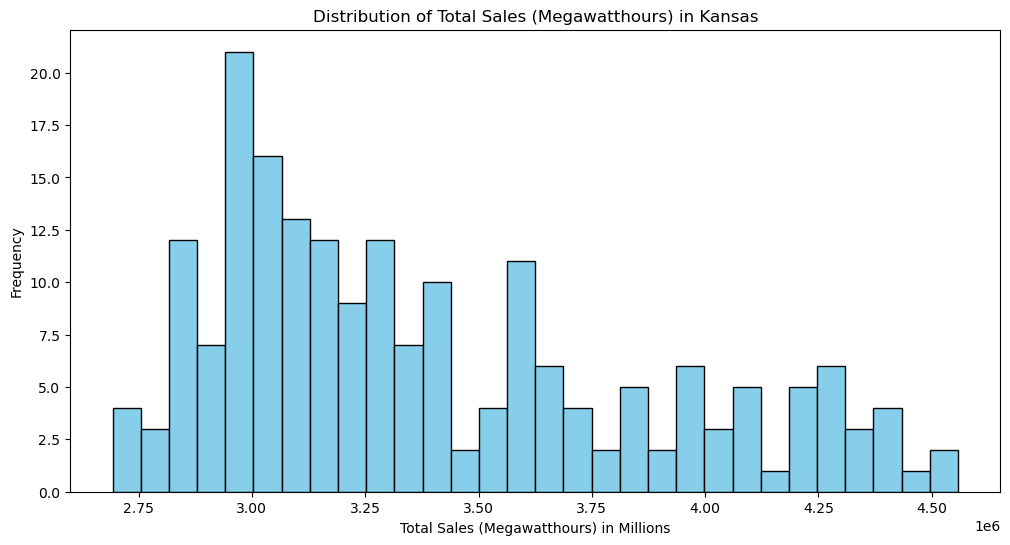

In [111]:
plt.figure(figsize=(12, 6))
plt.hist(eia_clean["Total_Sales_Megawatthours"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Total Sales (Megawatthours) in Millions")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales (Megawatthours) in Kansas")
plt.show()

### Total Megawatt Hours to Month

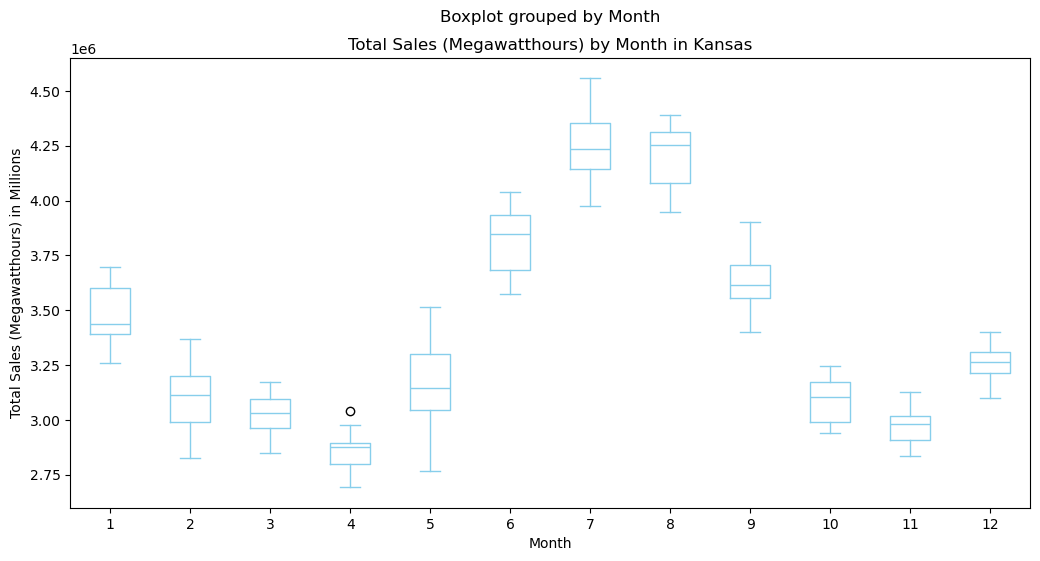

In [112]:
eia_clean.boxplot(column=
    "Total_Sales_Megawatthours",
    by="Month",
    figsize=(12, 6),
    grid=False,
    color="skyblue"
)

plt.title("Total Sales (Megawatthours) by Month in Kansas")
plt.xlabel("Month")
plt.ylabel("Total Sales (Megawatthours) in Millions")
plt.show()

### Megawatt Hours Over he Last 15 Years

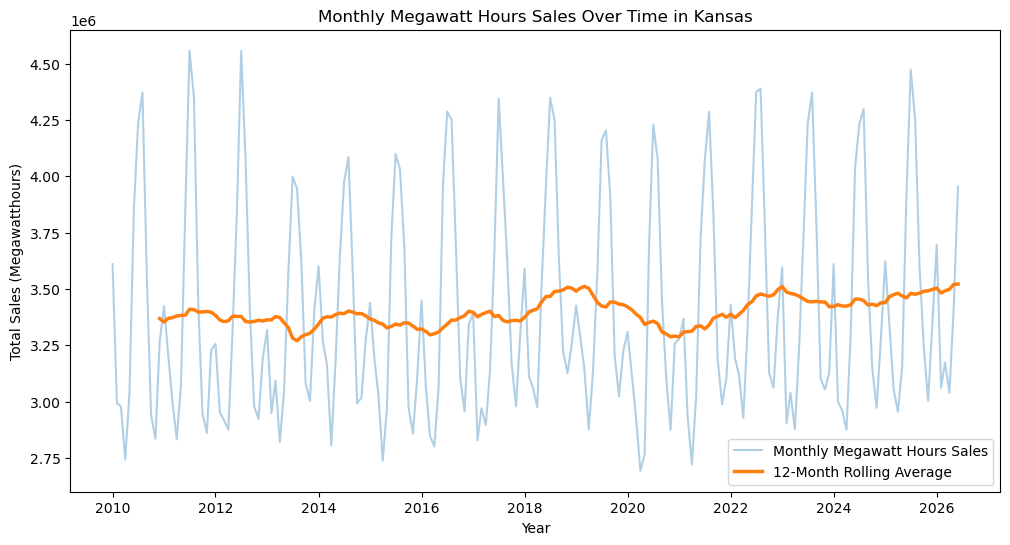

In [113]:
eia_clean["Rolling_12_Month"] = (
    eia_clean["Total_Sales_Megawatthours"]
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    eia_clean["Date"],
    eia_clean["Total_Sales_Megawatthours"],
    alpha=0.35,
    label="Monthly Megawatt Hours Sales"
)

plt.plot(
    eia_clean["Date"],
    eia_clean["Rolling_12_Month"],
    linewidth=2.5,
    label="12-Month Rolling Average"
)

plt.title("Monthly Megawatt Hours Sales Over Time in Kansas")
plt.xlabel("Year")
plt.ylabel("Total Sales (Megawatthours)")
plt.legend()
plt.show()

# Verifying Data Pipeline

In [114]:
print(eia_clean.shape)

print(
    eia_clean[
        ["Date", "Total_Sales_Megawatthours"]
    ].head()
)

print(
    eia_clean[
        ["Date", "Total_Sales_Megawatthours"]
    ].tail()
)
#Checking for missing Values
print(
    eia_clean[
        ["Date", "Total_Sales_Megawatthours"]
    ].isnull().sum()
)
#Checking if observations are in chronological order. This is important for time series analysis and forecasting.
print(
    eia_clean["Date"].is_monotonic_increasing
)
#Making sure the data isn''t object type. We need to make sure Python reads those as numbers.
print(eia_clean["Total_Sales_Megawatthours"].dtype)

(198, 10)
            Date  Total_Sales_Megawatthours
10063 2010-01-01                  3610636.0
10012 2010-02-01                  2991842.0
9961  2010-03-01                  2978921.0
9910  2010-04-01                  2742572.0
9859  2010-05-01                  3038553.0
          Date  Total_Sales_Megawatthours
220 2026-02-01                  3060997.6
169 2026-03-01                  3173574.1
118 2026-04-01                  3038359.7
67  2026-05-01                  3408626.4
16  2026-06-01                  3954433.8
Date                         0
Total_Sales_Megawatthours    0
dtype: int64
True
float64


Since we are using our EIA dataset to forecast demand, it is important that everything is working and clean. This confirms it by confirming no dublicates in our target variable or date, the dates are in chronological order, and the values are not seen as text. This gives us the go ahead to start engineering features to build our baseline model.

## Baseline Model/Engineering Features

In [115]:
#Creating features to convert to dummy varaibles.

model_data = eia_clean.copy()

model_data["Time_Index"] = np.arange(len(model_data))
#Converting month to categorical data.
model_data["Month"] = model_data["Month"].astype(str)
print(
    model_data[
        [
            "Date",
            "Month",
            "Time_Index",
            "Total_Sales_Megawatthours"
        ]
    ].head(15)
)

            Date Month  Time_Index  Total_Sales_Megawatthours
10063 2010-01-01     1           0                  3610636.0
10012 2010-02-01     2           1                  2991842.0
9961  2010-03-01     3           2                  2978921.0
9910  2010-04-01     4           3                  2742572.0
9859  2010-05-01     5           4                  3038553.0
9808  2010-06-01     6           5                  3848859.0
9757  2010-07-01     7           6                  4234490.0
9706  2010-08-01     8           7                  4373301.0
9655  2010-09-01     9           8                  3559715.0
9604  2010-10-01    10           9                  2941602.0
9553  2010-11-01    11          10                  2834543.0
9502  2010-12-01    12          11                  3265639.0
9451  2011-01-01     1          12                  3423634.0
9400  2011-02-01     2          13                  3199673.0
9349  2011-03-01     3          14                  3003544.0


In [116]:
#Splitting data into training and testing sets.
X = model_data[
    [
        "Month",
        "Time_Index"
    ]
]
#Two Predictors in X, and target variable in y

y = model_data["Total_Sales_Megawatthours"]

split_index = int(len(model_data) * 0.80)

#We cannot use the normal train_test_split function, because it randomly seperates our data.
#We cannot have that because we are working with time series data. We need to make sure the training data is before the testing data.

X_train = X.iloc[:split_index] #Starts at the beginning and stops at observation 158.
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

train_dates = model_data["Date"].iloc[:split_index]
test_dates = model_data["Date"].iloc[split_index:]

#Confirming the split of the data into training and testing sets.
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print(
    "Training period:",
    train_dates.min(),
    "to",
    train_dates.max()
)

print(
    "Testing period:",
    test_dates.min(),
    "to",
    test_dates.max()
)

Training observations: 158
Testing observations: 40
Training period: 2010-01-01 00:00:00 to 2023-02-01 00:00:00
Testing period: 2023-03-01 00:00:00 to 2026-06-01 00:00:00


In [117]:
#We need the model to understand that the months are categorical.
#We will use OneHotEncoder to convert the months into a format that the model can understand.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "month",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            ["Month"]
        ),
        (
            "time",
            "passthrough",
            ["Time_Index"]
        )
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('month',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Month']),
                                ('time', 'passthrough', ['Time_Index'])])


## Training Baseline Model using Linear Regression

In [118]:
#Baseline Model and Testing.
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regression", LinearRegression())
    ]
)
#Train model on training data. 
baseline_model.fit(X_train, y_train)

#Creating predictors for test period.
y_pred = baseline_model.predict(X_test)

#Comparison of actual vs predicted values for the test period.
comparison = pd.DataFrame({
    "Date": test_dates,
    "Actual_MWh": y_test,
    "Predicted_MWh": y_pred
})

print(comparison.head(10))

           Date  Actual_MWh  Predicted_MWh
2005 2023-03-01   3038736.9   3.051174e+06
1954 2023-04-01   2876495.2   2.859137e+06
1903 2023-05-01   3234551.2   3.158264e+06
1852 2023-06-01   3729071.0   3.801495e+06
1801 2023-07-01   4234499.9   4.285211e+06
1750 2023-08-01   4372416.1   4.213930e+06
1699 2023-09-01   3784199.1   3.660844e+06
1648 2023-10-01   3101536.4   3.115647e+06
1597 2023-11-01   3052902.7   2.997886e+06
1546 2023-12-01   3128849.8   3.291084e+06


## Evalution of Performance

In [119]:
#Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:,.0f} MWh")

#Root Mean Squared Error (RMSE)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"RMSE: {rmse:,.0f} MWh")

#R-squared (R²)
r2 = r2_score(y_test, y_pred)

print(f"R²: {r2:.3f}")

MAE: 93,857 MWh
RMSE: 114,183 MWh
R²: 0.941


These metrics are very important because we want our model to accurately predict electricity demand, so that we can use that information to guide projects, create proposals, and manage costs of renewable energy. 

## Baseline Model Train/Test Findings

This is a very good starting point for modeling. Our baseline model was able to explain about 94% of variation in electricity, and we were about 100,000 MWh off per month on average. Considering that a month can have anywhere between 3 to 4 million MWh, that is a pretty encouraging baseline model. This will help us forecast demand, from which we can then use our cost data to also forecast the cost of wind and solar energy to meet 100% of that demand. I believe this is a very good step in the right direction for this project. One limitation of this analysis is that it cannot predict extreme events. So if in 2028, there was a massive heat wave in March, that could affect the electricity numbers. However, this is still a good basis.

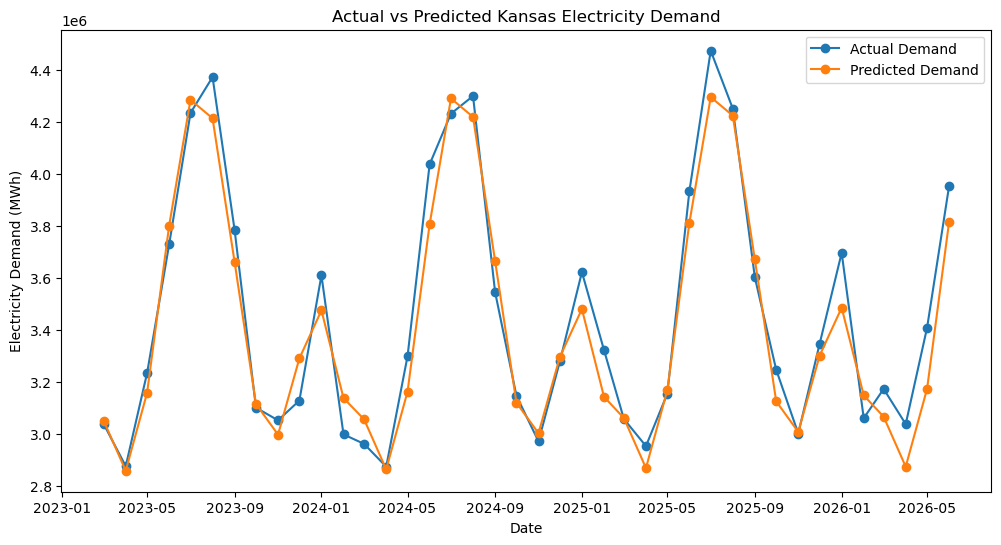

In [120]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    y_test,
    label="Actual Demand",
    marker="o"
)

plt.plot(
    test_dates,
    y_pred,
    label="Predicted Demand",
    marker="o"
)

plt.title("Actual vs Predicted Kansas Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MWh)")
plt.legend()

plt.show()

## Retraining Model to Predict Next 5 Years

In [121]:
#Retrain model to learn from all 198 months, and then use that to predict the next 5 years of electricity demand in Kansas. 
baseline_model.fit(X, y)

future_dates = pd.date_range(
    start="2027-01-01",
    periods=60,
    freq="MS"
)

#Creating a DataFrame for future predictions with the same structure as the training data.
future = pd.DataFrame({
    "Date": future_dates
})
future["Month"] = future["Date"].dt.month.astype(str)

last_date = model_data["Date"].max()
forecast_start = pd.Timestamp("2027-01-01")

month_gap = (
    (forecast_start.year - last_date.year) * 12
    + (forecast_start.month - last_date.month)
)

future["Time_Index"] = (
    model_data["Time_Index"].iloc[-1]
    + month_gap
    + np.arange(len(future))
)

future.head(15)

,Date,Month,Time_Index
0,2027-01-01,1,204
1,2027-02-01,2,205
2,2027-03-01,3,206
3,2027-04-01,4,207
4,2027-05-01,5,208
5,2027-06-01,6,209
6,2027-07-01,7,210
7,2027-08-01,8,211
8,2027-09-01,9,212
9,2027-10-01,10,213


In [122]:
#Generating the Demand Forecast for the next 5 years in Kansas.
future["Predicted_Demand_MWh"] = baseline_model.predict(
    future[
        [
            "Month",
            "Time_Index"
        ]
    ]
)

future.head(15)


,Date,Month,Time_Index,Predicted_Demand_MWh
0,2027-01-01,1,204,3.546746e+06
1,2027-02-01,2,205,3.178173e+06
2,2027-03-01,3,206,3.098626e+06
3,2027-04-01,4,207,2.923017e+06
4,2027-05-01,5,208,3.231451e+06
5,2027-06-01,6,209,3.873661e+06
6,2027-07-01,7,210,4.338675e+06
7,2027-08-01,8,211,4.279715e+06
8,2027-09-01,9,212,3.705920e+06
9,2027-10-01,10,213,3.173155e+06


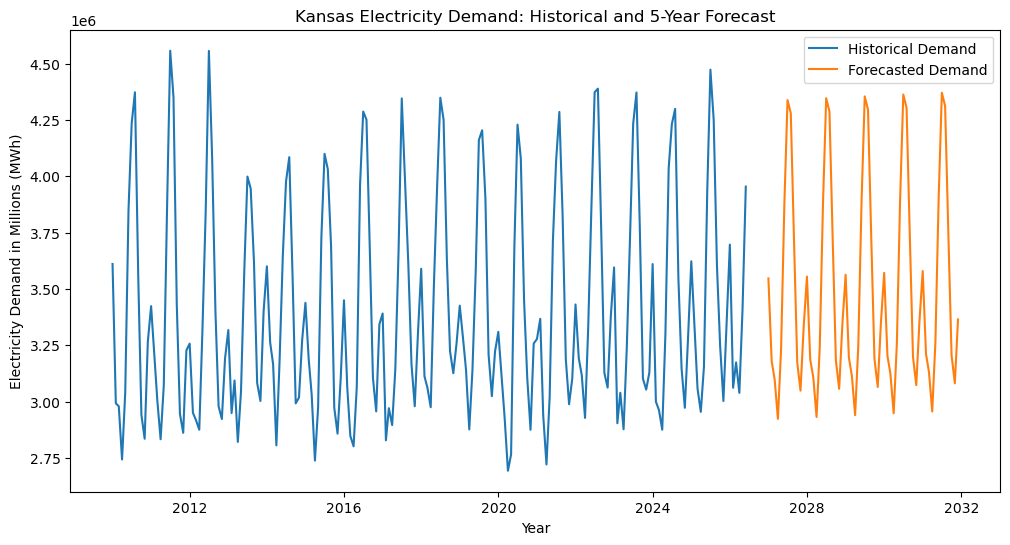

In [123]:
plt.figure(figsize=(12, 6))

plt.plot(
    model_data["Date"],
    model_data["Total_Sales_Megawatthours"],
    label="Historical Demand"
)

plt.plot(
    future["Date"],
    future["Predicted_Demand_MWh"],
    label="Forecasted Demand"
)

plt.title("Kansas Electricity Demand: Historical and 5-Year Forecast")
plt.xlabel("Year")
plt.ylabel("Electricity Demand in Millions (MWh)")
plt.legend()

plt.show()

#There is a gap between July 2026 and January 2027 because the historical data ends in July.

## Predicting Cost to meet Demand, Comparison

In [124]:
#First, we need to convert our forecasted demand into a yearly demand since ATB cost data is based on year.
future["Year"] = future["Date"].dt.year
annual_forecast = (
    future
    .groupby("Year", as_index=False)
    ["Predicted_Demand_MWh"]
    .sum()
)
annual_forecast.head(5)

,Year,Predicted_Demand_MWh
0,2027,4.172914e+07
1,2028,4.182706e+07
2,2029,4.192499e+07
3,2030,4.202291e+07
4,2031,4.212083e+07


In [125]:
# Filter ATB forecast for the years 2027-2031
atb_forecast = atb_model[
    atb_model["Year"].between(2027, 2031)
].copy()

print(atb_forecast.head(10))

#Merging ATB data with annual demand forecast.
cost_model = annual_forecast.merge(
    atb_forecast,
    on="Year",
    how="inner"
)
print(cost_model.head(10))

core_metric_parameter     technology  Year        CAPEX        CF   Fixed_OM
4                      LandbasedWind  2027  1775.395625  0.448103  38.474860
5                      LandbasedWind  2028  1727.227269  0.451677  37.343575
6                      LandbasedWind  2029  1679.058912  0.455265  36.212290
7                      LandbasedWind  2030  1630.890555  0.458866  35.081005
8                      LandbasedWind  2031  1582.722198  0.462482  33.949720
42                         UtilityPV  2027  1344.985039  0.266796  22.466114
43                         UtilityPV  2028  1284.731407  0.268421  21.766007
44                         UtilityPV  2029  1224.477775  0.270046  21.079489
45                         UtilityPV  2030  1164.224143  0.271671  20.405561
46                         UtilityPV  2031  1131.747947  0.273296  20.114959
   Year  Predicted_Demand_MWh     technology        CAPEX        CF   Fixed_OM
0  2027          4.172914e+07  LandbasedWind  1775.395625  0.448103  38.47

In [126]:
#Calculating 2027 Wind Cost for CAPEX and Fixed O&M
wind_2027 = cost_model[
    (cost_model["Year"] == 2027)
    &
    (cost_model["technology"] == "LandbasedWind")
].iloc[0]

required_capacity_mw = (
    wind_2027["Predicted_Demand_MWh"]
    /
    (
        8760
        * wind_2027["CF"]
    )
)

required_capacity_kw = required_capacity_mw * 1000

capex_cost = (
    required_capacity_kw
    * wind_2027["CAPEX"]
)

print(f"2027 Wind CAPEX Cost: ${capex_cost:,.2f}")

fixed_om_cost = (
    required_capacity_kw
    * wind_2027["Fixed_OM"]
)

print(
    f"2027 Wind Fixed O&M Cost: ${fixed_om_cost:,.2f}"
)

2027 Wind CAPEX Cost: $18,873,528,049.99
2027 Wind Fixed O&M Cost: $409,011,005.24


In [127]:
#Now we caclulate required capacity for wind and solar.
cost_model["Required_Capacity_MW"] = (
    cost_model["Predicted_Demand_MWh"]
    /
    (
        8760
        * cost_model["CF"]
    )
)
cost_model["Required_Capacity_kW"] = (
    cost_model["Required_Capacity_MW"]
    * 1000
)
print(
    cost_model[
        [
            "Year",
            "technology",
            "Predicted_Demand_MWh",
            "CF",
            "Required_Capacity_MW"
        ]
    ]
)

   Year     technology  Predicted_Demand_MWh        CF  Required_Capacity_MW
0  2027  LandbasedWind          4.172914e+07  0.448103          10630.604120
1  2027      UtilityPV          4.172914e+07  0.266796          17854.861039
2  2028  LandbasedWind          4.182706e+07  0.451677          10571.232668
3  2028      UtilityPV          4.182706e+07  0.268421          17788.409835
4  2029  LandbasedWind          4.192499e+07  0.455265          10512.475580
5  2029      UtilityPV          4.192499e+07  0.270046          17722.758403
6  2030  LandbasedWind          4.202291e+07  0.458866          10454.323734
7  2030      UtilityPV          4.202291e+07  0.271671          17657.892392
8  2031  LandbasedWind          4.212083e+07  0.462482          10396.768182
9  2031      UtilityPV          4.212083e+07  0.273296          17593.797790


In [128]:
cost_model["CAPEX_Cost"] = (
    cost_model["Required_Capacity_kW"]
    * cost_model["CAPEX"]
)

cost_model["Fixed_OM_Cost"] = (
    cost_model["Required_Capacity_kW"]
    * cost_model["Fixed_OM"]
)
cost_model["First_Year_Cost"] = (
    cost_model["CAPEX_Cost"]
    + cost_model["Fixed_OM_Cost"]
)
print(
    cost_model[
        [
            "Year",
            "technology",
            "Required_Capacity_MW",
            "CAPEX_Cost",
            "Fixed_OM_Cost",
            "First_Year_Cost"
        ]
    ]
)

   Year     technology  Required_Capacity_MW    CAPEX_Cost  Fixed_OM_Cost  \
0  2027  LandbasedWind          10630.604120  1.887353e+10   4.090110e+08   
1  2027      UtilityPV          17854.861039  2.401452e+10   4.011293e+08   
2  2028  LandbasedWind          10571.232668  1.825892e+10   3.947676e+08   
3  2028      UtilityPV          17788.409835  2.285333e+10   3.871827e+08   
4  2029  LandbasedWind          10512.475580  1.765107e+10   3.806808e+08   
5  2029      UtilityPV          17722.758403  2.170112e+10   3.735867e+08   
6  2030  LandbasedWind          10454.323734  1.704986e+10   3.667482e+08   
7  2030      UtilityPV          17657.892392  2.055774e+10   3.603192e+08   
8  2031  LandbasedWind          10396.768182  1.645520e+10   3.529674e+08   
9  2031      UtilityPV          17593.797790  1.991174e+10   3.538985e+08   

   First_Year_Cost  
0     1.928254e+10  
1     2.441565e+10  
2     1.865369e+10  
3     2.324051e+10  
4     1.803175e+10  
5     2.207471e+10  
6    

## Final MVP Findings
After using our forecast model to predict demand for the next five years, we then used our ATB cost data to find out how much it would cost to meet that demand every year using only wind and solar. We calculated the costs for building, operating, and maintenance of land based wind systems to meet that demand. Then did the same for solar. What we found is that Land Based Wind is cheaper than solar. However, both electricity systems go down in price every year. This is because we can assume that Kansas is going to continue to build and improve on the previous year, cutting the cost. 